# 02 — Temporal Dynamics of ERK and FoxO

## Student Notebook

This notebook moves from **what is in the dataset** to **how signaling changes over time**.

We focus on three temporal questions:

- how the average ERK and FoxO reporter signals evolve over the course of the experiment,
- how much cell-to-cell variability exists at each time point,
- what single-cell trajectories look like before averaging washes out their structure.

The main idea is important: a signaling dataset is not only about differences in mean level. It is also about **when signals change, how strongly they fluctuate, and how heterogeneous cells are across time**.

In [5]:
from pathlib import Path
import math
import os
import tempfile

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mpl-config'))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)

ROOT = Path.cwd()
if not (ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz').exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH = ROOT / '01-readme-experiment-description_2022-04-05.csv'

meta = pd.read_csv(META_PATH, encoding='utf-8-sig').rename(columns={'Site': 'Image_Metadata_Site'})
meta['Image_Metadata_Site'] = meta['Image_Metadata_Site'].astype(int)
site_to_mutation = meta.set_index('Image_Metadata_Site')['Mutation'].to_dict()
frame_to_min = float(meta['Acquisition_frequency_min'].iloc[0])

print('Data file:', DATA_PATH)
print('Frame interval [min]:', frame_to_min)
print('Mutations:', sorted(meta['Mutation'].unique()))

Data file: /Users/krzysiek/PROJECTS-MIMUW/UW-SysBiol-Project2/single-cell-tracks_exp1-6_noErbB2.csv.gz
Frame interval [min]: 5.0
Mutations: ['AKT1_E17K', 'ErbB2', 'PIK3CA_E545K', 'PIK3CA_H1047R', 'PTEN_del', 'WT']


## What Are We Exploring Here?

A time-resolved signaling dataset lets us ask questions that do not make sense in a static endpoint experiment.

In this notebook, each visualization should be read with a temporal mindset:

- the x-axis often represents biological time rather than arbitrary row order,
- smooth population curves summarize many cells, but they can hide pulses and heterogeneity,
- variability over time can be biologically interesting, not just statistical noise.

As you read the plots, keep asking:

- are we seeing a stable baseline, a trend, a transient response, or fluctuating dynamics?
- do ERK and FoxO appear to behave similarly or differently over time?
- are mutation effects visible mainly in the mean, or also in the variability?

In [6]:
USECOLS = ['Image_Metadata_Site', 'Image_Metadata_T', 'ERKKTR_ratio', 'FoxO3A_ratio']
CHUNKSIZE = 1_000_000

time_parts = []
for chunk in pd.read_csv(DATA_PATH, usecols=USECOLS, chunksize=CHUNKSIZE):
    chunk['Mutation'] = chunk['Image_Metadata_Site'].map(site_to_mutation)
    grouped = (
        chunk
        .groupby(['Mutation', 'Image_Metadata_T'])
        .agg(
            ERK_sum=('ERKKTR_ratio', 'sum'),
            ERK_sumsq=('ERKKTR_ratio', lambda s: np.square(s.astype(float)).sum()),
            ERK_count=('ERKKTR_ratio', 'count'),
            FoxO_sum=('FoxO3A_ratio', 'sum'),
            FoxO_sumsq=('FoxO3A_ratio', lambda s: np.square(s.astype(float)).sum()),
            FoxO_count=('FoxO3A_ratio', 'count'),
        )
    )
    time_parts.append(grouped)

temporal = pd.concat(time_parts).groupby(level=[0, 1]).sum().reset_index()
temporal['ERK_mean'] = temporal['ERK_sum'] / temporal['ERK_count']
temporal['FoxO_mean'] = temporal['FoxO_sum'] / temporal['FoxO_count']
temporal['ERK_std'] = np.sqrt(np.maximum(temporal['ERK_sumsq'] / temporal['ERK_count'] - temporal['ERK_mean'] ** 2, 0))
temporal['FoxO_std'] = np.sqrt(np.maximum(temporal['FoxO_sumsq'] / temporal['FoxO_count'] - temporal['FoxO_mean'] ** 2, 0))
temporal['time_h'] = temporal['Image_Metadata_T'] * frame_to_min / 60.0

display(temporal.head())
print('Rows in temporal summary:', len(temporal))

,Mutation,Image_Metadata_T,ERK_sum,ERK_sumsq,ERK_count,FoxO_sum,FoxO_sumsq,FoxO_count,ERK_mean,FoxO_mean,ERK_std,FoxO_std,time_h
0,AKT1_E17K,0,28952.261607,24940.171366,34327,46520.477197,64198.709265,34327,0.843425,1.355215,0.123209,0.183308,0.000000
1,AKT1_E17K,1,28933.626340,24903.255253,34336,46527.298710,64201.337128,34336,0.842662,1.355059,0.123299,0.183337,0.083333
2,AKT1_E17K,2,28887.522379,24823.475665,34325,46500.785591,64145.990678,34325,0.841588,1.354721,0.122141,0.183072,0.166667
3,AKT1_E17K,3,28859.258035,24772.843431,34325,46481.175620,64093.325850,34325,0.840765,1.354149,0.121773,0.183108,0.250000
4,AKT1_E17K,4,28830.009230,24730.163414,34315,46485.059507,64126.644603,34315,0.840158,1.354657,0.121721,0.183489,0.333333


Rows in temporal summary: 1290


## Population-Average Dynamics

The next figure shows mutation-level averages over time.

This is useful because it gives a first systems-level comparison: do some perturbations shift the whole trajectory upward, downward, or change its time dependence?

But this is not the whole story. Averages can make signaling look smoother than it really is at the single-cell level.
So while reading these curves, notice both:

- the **mean trajectory** itself,
- the **spread across cells** at each time point.

Large spread can mean that cells under the same mutation are not behaving uniformly.

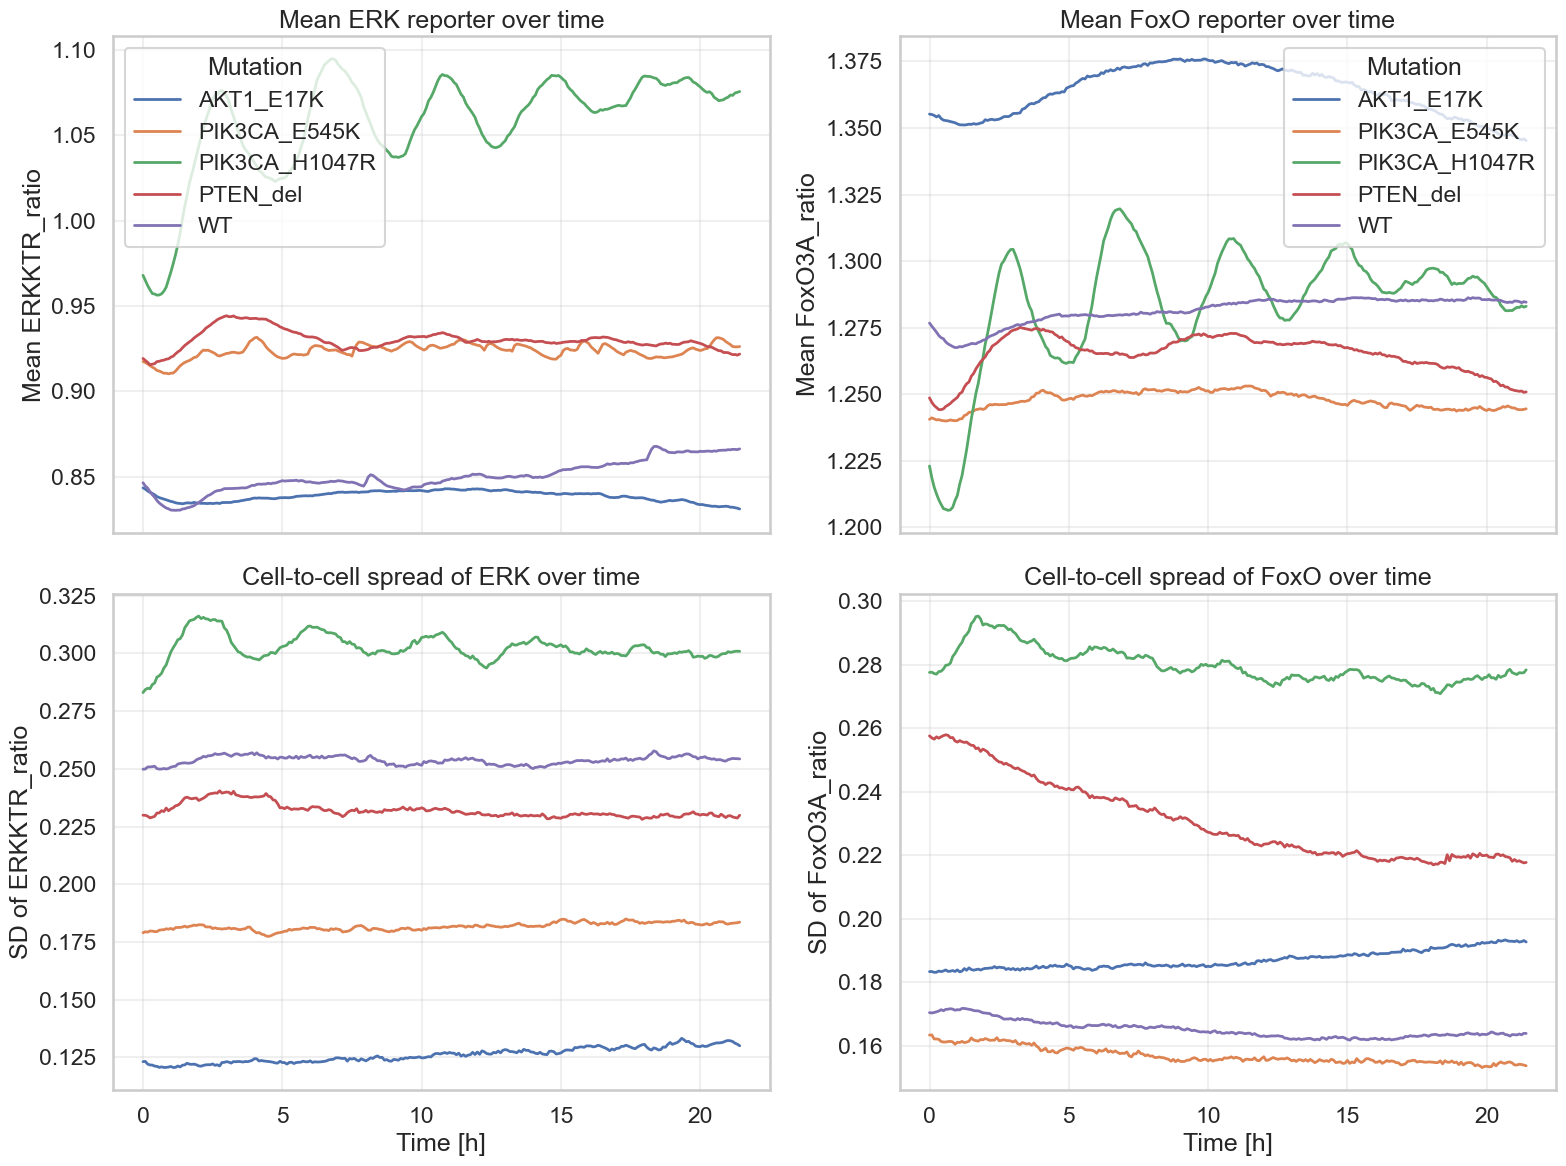

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col')

sns.lineplot(data=temporal, x='time_h', y='ERK_mean', hue='Mutation', linewidth=2, ax=axes[0, 0])
axes[0, 0].set_title('Mean ERK reporter over time')
axes[0, 0].set_ylabel('Mean ERKKTR_ratio')

sns.lineplot(data=temporal, x='time_h', y='FoxO_mean', hue='Mutation', linewidth=2, ax=axes[0, 1])
axes[0, 1].set_title('Mean FoxO reporter over time')
axes[0, 1].set_ylabel('Mean FoxO3A_ratio')

sns.lineplot(data=temporal, x='time_h', y='ERK_std', hue='Mutation', linewidth=2, ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Cell-to-cell spread of ERK over time')
axes[1, 0].set_ylabel('SD of ERKKTR_ratio')
axes[1, 0].set_xlabel('Time [h]')

sns.lineplot(data=temporal, x='time_h', y='FoxO_std', hue='Mutation', linewidth=2, ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Cell-to-cell spread of FoxO over time')
axes[1, 1].set_ylabel('SD of FoxO3A_ratio')
axes[1, 1].set_xlabel('Time [h]')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()

## From Population Curves Back to Single Cells

To understand what averaging may hide, we now look at a small set of individual trajectories.

This is pedagogically important because signaling is often interesting precisely when cells are **not** perfectly synchronized.
If individual traces fluctuate, pulse, or drift in different ways, then a smooth average can be misleading.

In the next plot, do not ask only "which mutation is highest?"
Also ask:

- how noisy or smooth are individual trajectories?
- do cells from the same mutation all behave similarly?
- does ERK seem more pulsatile than FoxO, or vice versa?

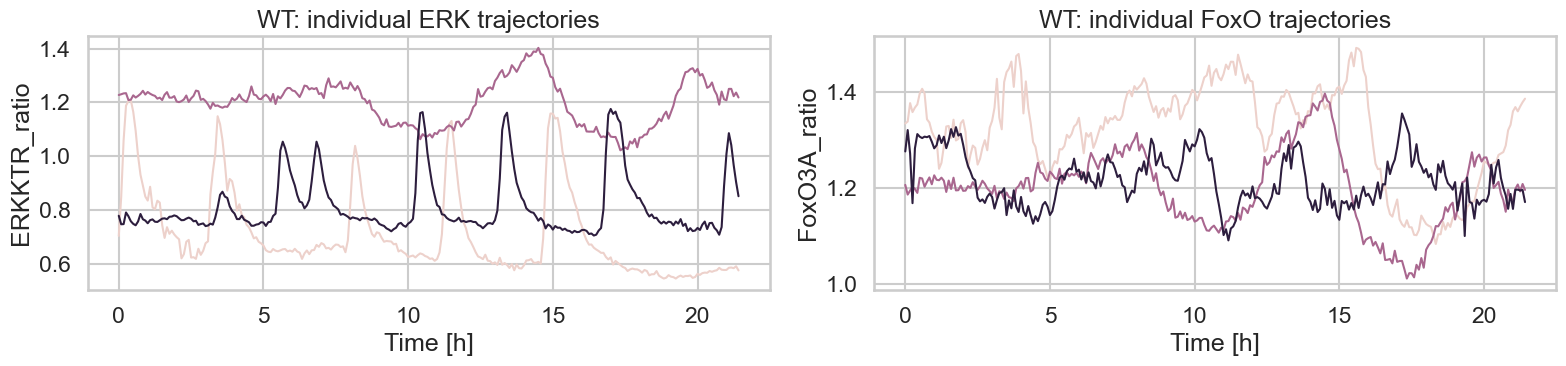

In [8]:
track_cols = ['Exp_ID', 'Image_Metadata_Site', 'track_id', 'Image_Metadata_T', 'ERKKTR_ratio', 'FoxO3A_ratio']
track_sample = pd.read_csv(DATA_PATH, usecols=track_cols, nrows=400_000)
track_sample['Mutation'] = track_sample['Image_Metadata_Site'].map(site_to_mutation)
track_sample['time_h'] = track_sample['Image_Metadata_T'] * frame_to_min / 60.0

track_lengths = (
    track_sample
    .groupby(['Mutation', 'Exp_ID', 'Image_Metadata_Site', 'track_id'])
    .size()
    .reset_index(name='n_obs')
    .sort_values(['Mutation', 'n_obs'], ascending=[True, False])
)

selected_tracks = track_lengths.groupby('Mutation').head(3).copy()
selected_mutations = selected_tracks['Mutation'].dropna().drop_duplicates().sort_values().head(4).tolist()
selected_tracks = selected_tracks[selected_tracks['Mutation'].isin(selected_mutations)]

sampled_traces = track_sample.merge(
    selected_tracks[['Mutation', 'Exp_ID', 'Image_Metadata_Site', 'track_id']],
    on=['Mutation', 'Exp_ID', 'Image_Metadata_Site', 'track_id'],
    how='inner'
)

fig, axes = plt.subplots(len(selected_mutations), 2, figsize=(16, 4 * len(selected_mutations)), sharex=True)
if len(selected_mutations) == 1:
    axes = np.array([axes])

for row_idx, mutation in enumerate(selected_mutations):
    data = sampled_traces[sampled_traces['Mutation'] == mutation]
    sns.lineplot(data=data, x='time_h', y='ERKKTR_ratio', hue='track_id', estimator=None, lw=1.5, legend=False, ax=axes[row_idx, 0])
    axes[row_idx, 0].set_title(f'{mutation}: individual ERK trajectories')
    axes[row_idx, 0].set_ylabel('ERKKTR_ratio')

    sns.lineplot(data=data, x='time_h', y='FoxO3A_ratio', hue='track_id', estimator=None, lw=1.5, legend=False, ax=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f'{mutation}: individual FoxO trajectories')
    axes[row_idx, 1].set_ylabel('FoxO3A_ratio')

axes[-1, 0].set_xlabel('Time [h]')
axes[-1, 1].set_xlabel('Time [h]')
plt.tight_layout()

## What to Take Away

This notebook should leave you with a richer idea of temporal analysis:

- mutation effects can appear in average signal level,
- they can also appear in time dependence and in the amount of cell-to-cell variability,
- single-cell traces can reveal heterogeneity that is invisible in population means.

That is why temporal analysis is not just plotting time on the x-axis. It is about deciding whether the main biological signal is in the mean trend, the fluctuations, the heterogeneity, or some combination of all three.